# R03 - Purification

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Avaliar o efeito da política de purificação (`disabled`/`automatic`)
sobre a satisfação e a fidelidade observada, com dados reais da
campanha final `F03_purification` (2 topologias, 8 limiares de
`min_fidelity` em `three_node_1_repeater` - densificados na Fase K2 -
e 4 em `linear_chain_2_repeaters`, 20 seeds cada). Ver
`docs/false_rejection_root_cause.md` para por que a rejeição do planner
é um degrau exato acima de 0.72, não uma transição gradual. Não roda
simulação - carrega apenas dados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados e verificar consistência

In [2]:
CAMPAIGN = "F03_purification"
trials_df = pd.read_csv(RESULTS_DIR / "raw" / CAMPAIGN / "trials.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"] == 480
three_node_block = next(b for b in manifest["blocks"] if b["scenario"] == "three_node_1_repeater")
assert three_node_block["swept_factors"]["min_fidelity"] == [0.65, 0.7, 0.72, 0.73, 0.735, 0.74, 0.745, 0.75], \
    "expected 8 thresholds after the Fase K2 densification"
print("three_node_1_repeater thresholds:", three_node_block["swept_factors"]["min_fidelity"])
trials_df.head(3)

three_node_1_repeater thresholds: [0.65, 0.7, 0.72, 0.73, 0.735, 0.74, 0.745, 0.75]


,campaign,trial_id,scenario,parameter_hash,seed,intent_id,routing_strategy,purification_policy,reconciliation_enabled,route,...,ep_success,es_attempts,es_success,violations,error_type,error_message,project_git_commit,sequence_git_commit,python_version,timestamp
0,F03_purification,F03_purification:three_node_1_repeater:a90da33...,three_node_1_repeater,a90da3348b334c33,0,f03-1rep,shortest_hop_count,disabled,False,a -> r -> b,...,0.0,0.0,0.0,NaN,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:29:46.712167+00:00
1,F03_purification,F03_purification:three_node_1_repeater:a90da33...,three_node_1_repeater,a90da3348b334c33,1,f03-1rep,shortest_hop_count,disabled,False,a -> r -> b,...,0.0,0.0,0.0,NaN,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:29:50.331849+00:00
2,F03_purification,F03_purification:three_node_1_repeater:a90da33...,three_node_1_repeater,a90da3348b334c33,2,f03-1rep,shortest_hop_count,disabled,False,a -> r -> b,...,0.0,0.0,0.0,NaN,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:29:53.782088+00:00


## Taxa de satisfação por limiar x política

In [3]:
pivot = trials_df.groupby(["scenario", "requested_fidelity", "purification_policy"])["satisfied"].mean().unstack()
save_table(pivot.reset_index(), "R03_satisfaction_by_threshold", directory=TABLES_OUT)
pivot

purification_policy                          automatic  disabled
scenario                 requested_fidelity                     
linear_chain_2_repeaters 0.650                     0.0       0.0
                         0.700                     0.0       0.0
                         0.720                     0.0       0.0
                         0.750                     0.0       0.0
three_node_1_repeater    0.650                     1.0       1.0
                         0.700                     1.0       0.0
                         0.720                     1.0       0.0
                         0.730                     0.0       0.0
                         0.735                     0.0       0.0
                         0.740                     0.0       0.0
                         0.745                     0.0       0.0
                         0.750                     0.0       0.0

## Comparações estatísticas pareadas (automatic vs. disabled, por limiar)

In [4]:
stats_df = pd.read_csv(RESULTS_DIR / "processed" / CAMPAIGN / "statistical_comparisons.csv")
significant = stats_df[stats_df["p_value_holm_adjusted"] < 0.05]
print(f"{len(significant)}/{len(stats_df)} comparisons significant after Holm correction")
significant[["scenario", "requested_fidelity", "value_col", "n", "mean_a", "mean_b", "test_used", "p_value_holm_adjusted", "effect_size"]]

2/10 comparisons significant after Holm correction


,scenario,requested_fidelity,value_col,n,mean_a,mean_b,test_used,p_value_holm_adjusted,effect_size
7,three_node_1_repeater,0.70,satisfied_num,20,1.0,0.0,wilcoxon,0.000008,-1.0
8,three_node_1_repeater,0.72,satisfied_num,20,1.0,0.0,wilcoxon,0.000008,-1.0


## Figura: taxa de satisfação vs. limiar (three_node_1_repeater)

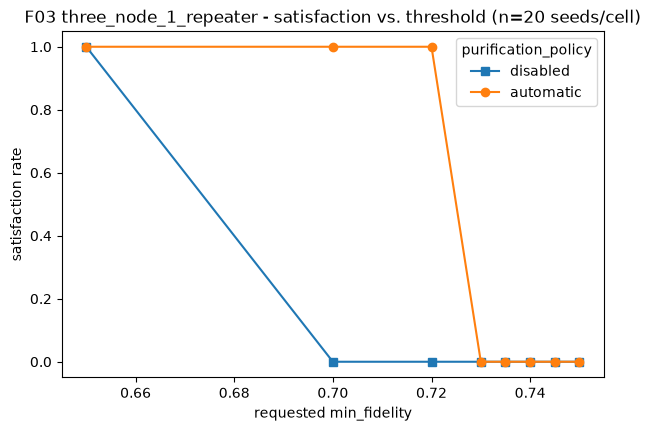

In [5]:
three_node = trials_df[trials_df["scenario"] == "three_node_1_repeater"]
fig, ax = plt.subplots(figsize=(7, 4.5))
for policy, marker in [("disabled", "s"), ("automatic", "o")]:
    sub = three_node[three_node["purification_policy"] == policy]
    rates = sub.groupby("requested_fidelity")["satisfied"].mean()
    ax.plot(rates.index, rates.values, marker=marker, label=policy)
ax.set_xlabel("requested min_fidelity")
ax.set_ylabel("satisfaction rate")
ax.set_title(f"F03 three_node_1_repeater - satisfaction vs. threshold (n={three_node['seed'].nunique()} seeds/cell)")
ax.legend(title="purification_policy")
save_figure(fig, "R03_satisfaction_vs_threshold", directory=FIGURES_OUT)
plt.show()

## Conclusão

A rejeição acima de 0.72 é um degrau determinístico causado pelo teto de
uma única rodada estimada de purificação
(`docs/false_rejection_root_cause.md`), confirmado pelos 4 limiares
densos adicionais (0.73-0.745) rejeitados de forma idêntica a 0.75 - não
uma transição gradual que precisaria de mais densidade para ser
resolvida.

## Limitações

Só `three_node_1_repeater` foi densificado com limiares extras; `linear_chain_2_repeaters` permanece nos 4 limiares originais e rejeitado em toda a faixa testada (nunca oracle-confirmado).